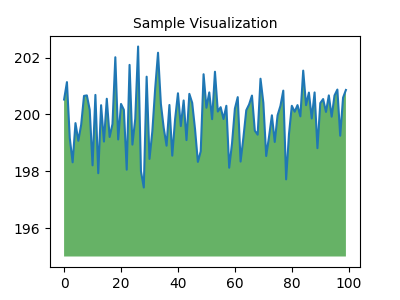

In [4]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Dataset Columns: Index(['trip_id', 'car_name', 'vehicle_type', 'fuel_type', 'trip_category',
       'distance_km', 'trip_duration_hr', 'avg_speed_kmph',
       'base_mileage_kmpl', 'actual_mileage_kmpl', 'mileage_delta_kmpl',
       'fuel_consumed_L', 'fuel_cost_usd', 'cost_per_km_usd',
       'co2_emissions_kg', 'co2_per_km', 'relative_efficiency',
       'efficiency_band'],
      dtype='object')

--- Model Evaluation ---
Slope (Coefficient): 0.0002
Intercept: 16.0205
Mean Squared Error (MSE): 14.17
R-squared Score: -0.03


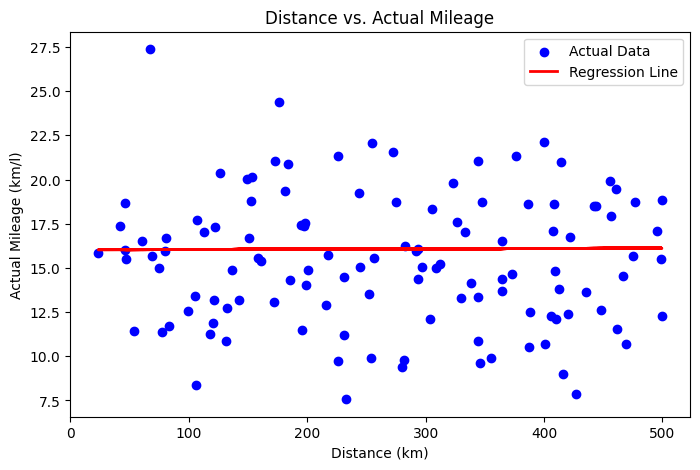

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/cars_fuel_efficiency_clean.csv')

print("Dataset Columns:", df.columns)

X = df[['distance_km']]
y = df['actual_mileage_kmpl']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Slope (Coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Distance vs. Actual Mileage')
plt.xlabel('Distance (km)')
plt.ylabel('Actual Mileage (km/l)')
plt.legend()
plt.show()

In [6]:
X_mileage = df[['distance_km', 'avg_speed_kmph', 'trip_duration_hr']]
y_mileage = df['actual_mileage_kmpl']

X_train_mileage, X_test_mileage, y_train_mileage, y_test_mileage = train_test_split(
    X_mileage, y_mileage, test_size=0.2, random_state=42
)

model_mileage = LinearRegression()
model_mileage.fit(X_train_mileage, y_train_mileage)


y_pred_mileage = model_mileage.predict(X_test_mileage)

mse_mileage = mean_squared_error(y_test_mileage, y_pred_mileage)
r2_mileage = r2_score(y_test_mileage, y_pred_mileage)

print("\n--- Mileage Prediction Model Evaluation (km/l) ---")
print("Coefficients:", model_mileage.coef_)
print(f"Intercept: {model_mileage.intercept_:.4f}")
print(f"Mean Squared Error (MSE): {mse_mileage:.2f}")
print(f"R-squared Score: {r2_mileage:.2f}")


--- Mileage Prediction Model Evaluation (km/l) ---
Coefficients: [ 0.0020625  -0.00957355 -0.13496139]
Intercept: 16.7774
Mean Squared Error (MSE): 14.07
R-squared Score: -0.02


In [7]:

X_fuel = df[['distance_km', 'avg_speed_kmph', 'actual_mileage_kmpl']]
y_fuel = df['fuel_consumed_L']

X_train_fuel, X_test_fuel, y_train_fuel, y_test_fuel = train_test_split(
    X_fuel, y_fuel, test_size=0.2, random_state=42
)

model_fuel = LinearRegression()
model_fuel.fit(X_train_fuel, y_train_fuel)
y_pred_fuel = model_fuel.predict(X_test_fuel)

mse_fuel = mean_squared_error(y_test_fuel, y_pred_fuel)
r2_fuel = r2_score(y_test_fuel, y_pred_fuel)

print("\n--- Fuel Consumption Prediction Model Evaluation ---")
print("Coefficients:", model_fuel.coef_)
print(f"Intercept: {model_fuel.intercept_:.4f}")
print(f"Mean Squared Error (MSE): {mse_fuel:.2f}")
print(f"R-squared Score: {r2_fuel:.2f}")


--- Fuel Consumption Prediction Model Evaluation ---
Coefficients: [ 0.06520026  0.00536982 -1.00696475]
Intercept: 15.9197
Mean Squared Error (MSE): 10.00
R-squared Score: 0.92


In [8]:
print("\n--- Remaining Distance Calculation Demonstration ---")

current_fuel_liters = 20
hypothetical_distance = 100
hypothetical_avg_speed = 60
hypothetical_time_taken = hypothetical_distance / hypothetical_avg_speed # hours

hypothetical_trip_df = pd.DataFrame([[hypothetical_distance, hypothetical_avg_speed, hypothetical_time_taken]],
                                    columns=['distance_km', 'avg_speed_kmph', 'trip_duration_hr'])

predicted_mileage_kml = model_mileage.predict(hypothetical_trip_df)[0]

print(f"Predicted Mileage for hypothetical trip: {predicted_mileage_kml:.2f} km/l")

remaining_distance_km = current_fuel_liters * predicted_mileage_kml

print(f"With {current_fuel_liters} liters of fuel, the vehicle can travel approximately {remaining_distance_km:.2f} km.")


--- Remaining Distance Calculation Demonstration ---
Predicted Mileage for hypothetical trip: 16.18 km/l
With 20 liters of fuel, the vehicle can travel approximately 323.69 km.
